In [1]:
# ── 1.0  IMPORTS ─────────────────────────────────────────────
import itertools
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset, Dataset


In [2]:
# Random seed — used throughout every notebook
RANDOM_STATE = 42

# ── 1.1  LOAD RAW DATA (exactly as in official dataset notebook) ──────────────
# We stream the dataset to avoid downloading the full corpus (~750 GB).
# We sample 50,000 reviews — the maximum recommended in the assessment brief.
print("=" * 60)
print("Loading Amazon Electronics Reviews (streaming 50,000 records)")
print("Source: McAuley-Lab/Amazon-Reviews-2023")
print("=" * 60)

REVIEWS_URL = (
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023"
    "/resolve/main/raw/review_categories/Electronics.jsonl"
)

ds_iter = load_dataset(
    "json",
    data_files=REVIEWS_URL,
    split="train",
    streaming=True
)

sample = list(itertools.islice(ds_iter, 50_000))
dataset = Dataset.from_list(sample)
df_raw = dataset.to_pandas()

print(f"\nRaw dataset loaded: {len(df_raw):,} reviews")
print(f"Columns: {list(df_raw.columns)}")


Loading Amazon Electronics Reviews (streaming 50,000 records)
Source: McAuley-Lab/Amazon-Reviews-2023

Raw dataset loaded: 50,000 reviews
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [3]:
# ── 1.2  INSPECT RAW DATA ──────────────────────────────────────
print("\n" + "=" * 60)
print("RAW DATA STRUCTURE")
print("=" * 60)
print(df_raw.head(3).to_string())
print("\nData types:")
print(df_raw.dtypes)
print("\nNull counts:")
print(df_raw.isnull().sum())



RAW DATA STRUCTURE
   rating                                    title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [4]:
# ── 1.3  PREVIEW RATING DISTRIBUTION (raw) ───────────────────
print("\n" + "=" * 60)
print("RATING DISTRIBUTION (raw, before preprocessing)")
print("=" * 60)
rating_counts = df_raw['rating'].value_counts().sort_index()
print(rating_counts)
print(f"\nNote: 4–5 star reviews dominate ({rating_counts[4.0]+rating_counts[5.0]:,} / {len(df_raw):,} = "
      f"{(rating_counts[4.0]+rating_counts[5.0])/len(df_raw)*100:.1f}%)")
print("This class imbalance is why we use Macro F1, not accuracy.")


RATING DISTRIBUTION (raw, before preprocessing)
rating
1.0     4144
2.0     2117
3.0     3412
4.0     7383
5.0    32944
Name: count, dtype: int64

Note: 4–5 star reviews dominate (40,327 / 50,000 = 80.7%)
This class imbalance is why we use Macro F1, not accuracy.


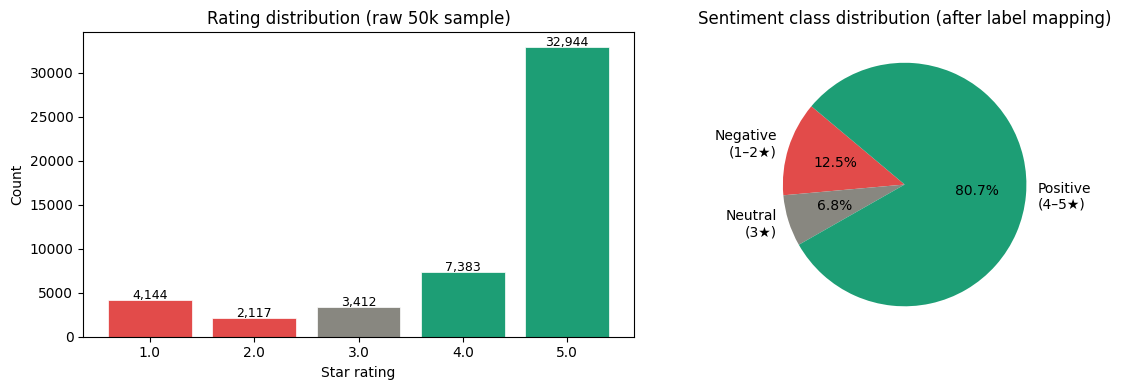

Saved: results/01_rating_distribution.png


In [5]:
# ── 1.4  PLOT RAW RATING DISTRIBUTION ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=['#E24B4A', '#E24B4A', '#888780', '#1D9E75', '#1D9E75'],
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('Rating distribution (raw 50k sample)', fontsize=12)
axes[0].set_xlabel('Star rating')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(zip(rating_counts.index, rating_counts.values)):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Sentiment class pie (after mapping)
class_labels = ['Negative\n(1–2★)', 'Neutral\n(3★)', 'Positive\n(4–5★)']
neg = rating_counts.get(1.0, 0) + rating_counts.get(2.0, 0)
neu = rating_counts.get(3.0, 0)
pos = rating_counts.get(4.0, 0) + rating_counts.get(5.0, 0)
axes[1].pie(
    [neg, neu, pos],
    labels=class_labels,
    autopct='%1.1f%%',
    colors=['#E24B4A', '#888780', '#1D9E75'],
    startangle=140
)
axes[1].set_title('Sentiment class distribution (after label mapping)', fontsize=12)

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/01_rating_distribution.png")


In [7]:
# ── 1.5  SAVE RAW DATA ────────────────────────────────────────
os.makedirs('../data', exist_ok=True)
df_raw.to_csv('../data/raw_50k.csv', index=False)
print(f"\nSaved raw data: data/raw_50k.csv ({len(df_raw):,} rows)")




Saved raw data: data/raw_50k.csv (50,000 rows)
